# Phân loại Fashion-MNIST: một mạng CNN, ba cách hiện thực

Notebook này xây dựng một mạng nơ-ron tích chập (CNN) để phân loại các ảnh
xám nhỏ về quần áo vào một trong mười danh mục, và xây dựng cùng một mạng đó
ba lần riêng biệt: một lần với mọi phép toán được viết tay bằng NumPy, một
lần với TensorFlow/Keras, và một lần với PyTorch. Kiến trúc, dữ liệu, cách
chia tập huấn luyện, và các siêu tham số đều được giữ cố định giữa cả ba,
nên bất kỳ khác biệt nào trong kết quả đều bắt nguồn từ chính cách hiện
thực chứ không phải từ ba thiết lập khác nhau.

Mỗi ảnh ở đây là một lưới 28x28 giá trị cường độ pixel, và các pixel lân
cận có liên hệ với nhau theo cách mà một mạng feedforward thông thường
không có cách nào khai thác được: một mạng coi mỗi pixel là một đầu vào
độc lập sẽ không có khái niệm rằng hai pixel liền kề có khả năng thuộc
cùng một cạnh hay kết cấu cao hơn so với hai pixel ở hai góc đối diện của
ảnh. Một lớp tích chập được thiết kế riêng để tận dụng cấu trúc cục bộ đó,
trượt một tập trọng số nhỏ qua ảnh để cùng một bộ phát hiện mẫu đã học có
thể được áp dụng ở mọi nơi thay vì phải học một bộ phát hiện riêng cho
từng vị trí pixel. Đó là lý do notebook này xây dựng một CNN thay vì một
mạng feedforward thông thường: kiến trúc được chọn theo đúng hình dạng của
dữ liệu, chứ không phải một lựa chọn cố định từ trước.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
import json
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## Nạp dữ liệu

Fashion-MNIST đi kèm sẵn trong bộ nạp dataset của Keras, nên không cần bước
tải thủ công ở đây. Cùng các mảng dữ liệu đã nạp đó được tái sử dụng bởi cả
ba cách hiện thực bên dưới, nên mỗi cách hiện thực đều huấn luyện và được
đánh giá trên đúng cùng một tập ảnh, theo đúng cùng một thứ tự, chứ không
chỉ là "cùng một bộ dữ liệu" trên danh nghĩa.

In [3]:
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.fashion_mnist.load_data()

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print("Train:", X_train_raw.shape, y_train.shape)
print("Test:", X_test_raw.shape, y_test.shape)
print("Pixel range before normalization:", X_train_raw.min(), "to", X_train_raw.max())

Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)
Pixel range before normalization: 0 to 255


## Tìm hiểu dữ liệu

Trước khi làm bất cứ điều gì khác, đáng để xác nhận cân bằng lớp và thực sự
nhìn qua một mẫu các ảnh, thay vì mặc định rằng một bộ dữ liệu benchmark nổi
tiếng không có vấn đề gì. Một cân bằng lớp bị lệch sẽ làm thay đổi cách đọc
các chỉ số bên dưới, và nhìn vào các ví dụ thực tế là cách duy nhất để phát
hiện những thứ như ảnh gán nhãn sai hoặc bị hỏng.

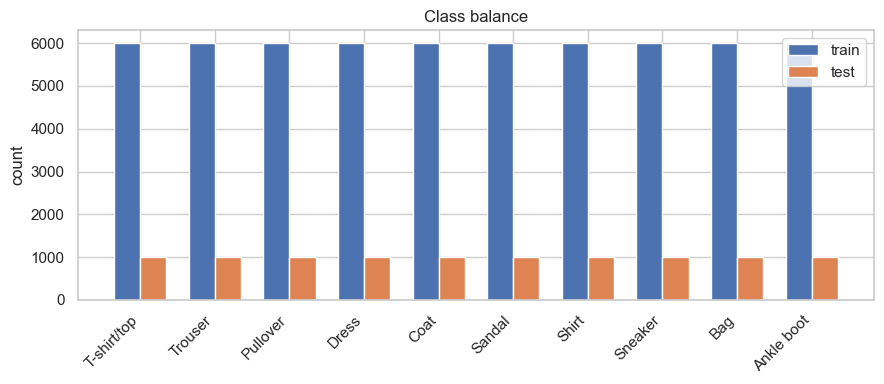

In [4]:
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

plt.figure(figsize=(9, 4))
x = np.arange(10)
width = 0.35
plt.bar(x - width/2, train_counts, width, label="train")
plt.bar(x + width/2, test_counts, width, label="test")
plt.xticks(x, CLASS_NAMES, rotation=45, ha="right")
plt.ylabel("count")
plt.title("Class balance")
plt.legend()
plt.tight_layout()
plt.show()

Mỗi lớp có đúng 6.000 ảnh huấn luyện và 1.000 ảnh kiểm tra. Đây là một bộ dữ
liệu benchmark được cố tình cân bằng, nên không cần điều chỉnh mất cân bằng
lớp ở đây: một mô hình chỉ luôn dự đoán một lớp duy nhất cũng chỉ đạt độ
chính xác 10%, chứ không phải một con số cao giả tạo như khi dữ liệu mất
cân bằng.

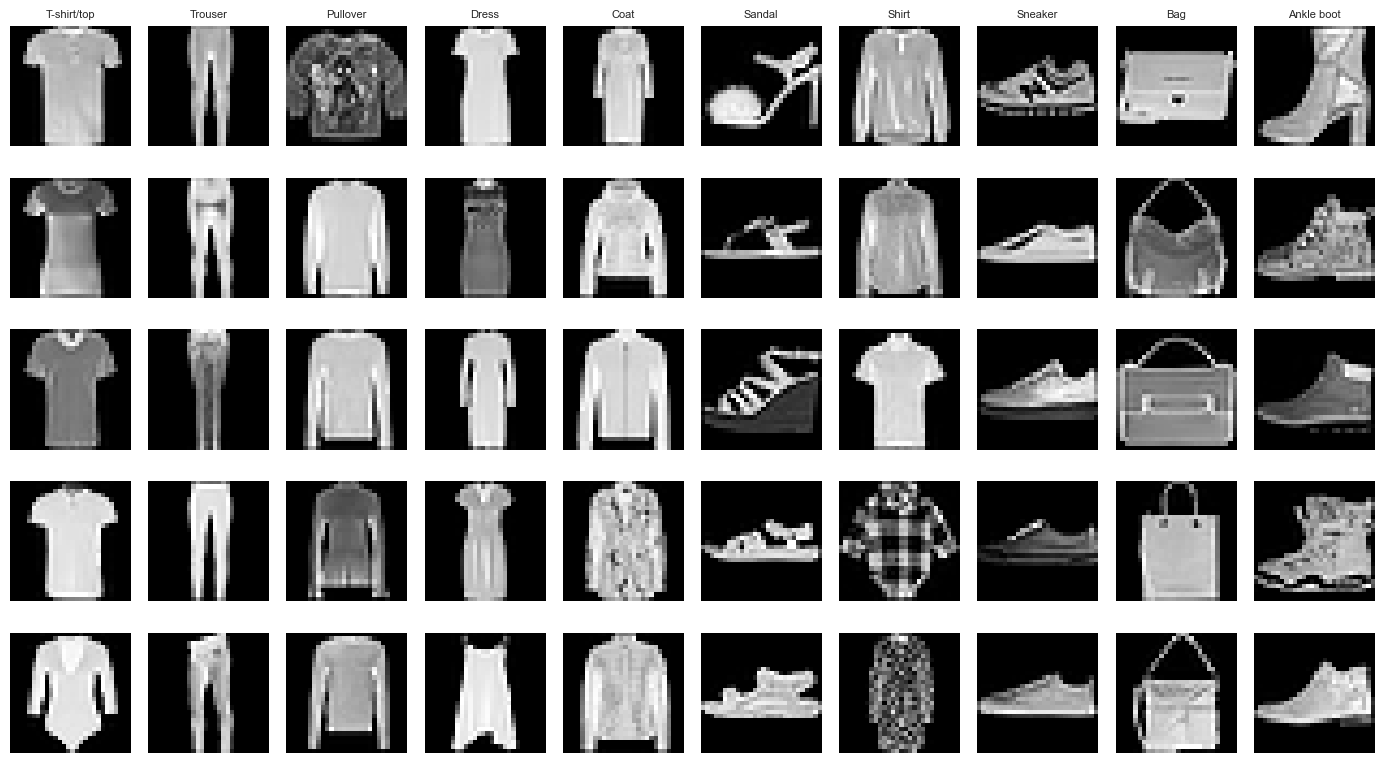

In [5]:
fig, axes = plt.subplots(5, 10, figsize=(14, 8))
rng = np.random.default_rng(RANDOM_SEED)
for class_idx in range(10):
    class_examples = np.where(y_train == class_idx)[0]
    chosen = rng.choice(class_examples, size=5, replace=False)
    for row, example_idx in enumerate(chosen):
        ax = axes[row, class_idx]
        ax.imshow(X_train_raw[example_idx], cmap="gray")
        ax.axis("off")
        if row == 0:
            ax.set_title(CLASS_NAMES[class_idx], fontsize=8)
plt.tight_layout()
plt.show()

Các lớp khác biệt rõ ràng với nhau trong những trường hợp hiển nhiên (một
chiếc sandal trông chẳng giống chiếc quần chút nào), nhưng một số cặp thực
sự mơ hồ ngay cả với mắt người: một vài ví dụ ở trên thuộc "Shirt",
"T-shirt/top", và "Pullover" trông giống nhau đến mức có thể mong đợi một
mức nhầm lẫn hợp lý giữa riêng ba lớp này ở bất kỳ mô hình nào trong ba mô
hình được huấn luyện bên dưới, chứ không hẳn là dấu hiệu một cách hiện thực
cụ thể nào đó bị lỗi.

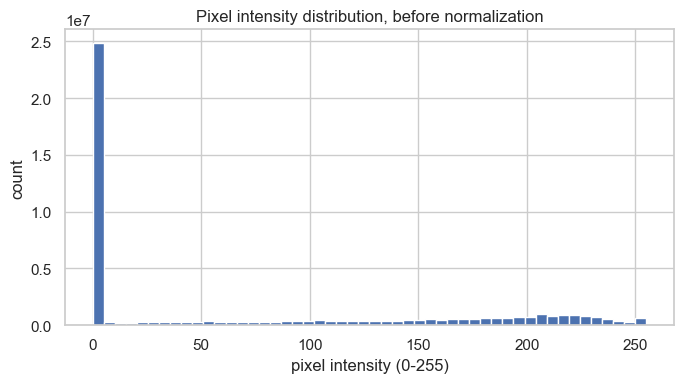

In [6]:
plt.figure(figsize=(7, 4))
plt.hist(X_train_raw.flatten(), bins=50, color="#4C72B0")
plt.xlabel("pixel intensity (0-255)")
plt.ylabel("count")
plt.title("Pixel intensity distribution, before normalization")
plt.tight_layout()
plt.show()

Đỉnh lớn tại giá trị 0 phản ánh việc phần lớn mỗi ảnh là nền đen thuần túy,
điều này hợp lý với các món đồ quần áo nhỏ, nằm giữa khung trên nền tối.
Điều này cũng khẳng định không có vấn đề mã hóa bất ngờ nào (chẳng hạn giá
trị nằm ngoài khoảng 0-255 dự kiến), nên việc chuẩn hóa bằng cách chia cho
255 bên dưới là an toàn mà không cần xử lý thêm.

## Biểu diễn dữ liệu

Có hai việc xảy ra trước khi dữ liệu này sẵn sàng để huấn luyện: giá trị
pixel được co giãn từ khoảng số nguyên 0-255 xuống số thực 0.0-1.0, và mảng
được reshape để thêm một trục kênh tường minh. Kernel của một phép tích
chập có shape dạng `(out_channels, in_channels, kh, kw)`: phép toán được
viết để cộng dồn trên bất kể bao nhiêu kênh mà đầu vào có tại mỗi pixel, dù
đó là 1 cho ảnh xám hay 3 cho ảnh màu. Một mảng `(28, 28)` thuần túy không
nói lên được có bao nhiêu kênh tồn tại tại mỗi pixel; `(1, 28, 28)` thì có,
nên shape phải mang trục đó một cách tường minh ngay cả khi chỉ có một kênh
để cộng dồn. Bản thân bước co giãn không cần bước nào
chỉ-tính-trên-tập-huấn-luyện: việc chia cho một hằng số cố định (255) không
dùng thống kê nào tính từ dữ liệu, nên không có gì có thể rò rỉ từ tập kiểm
tra vào bước này, khác với một bước chuẩn hóa (standardization) sẽ cần mean
và độ lệch chuẩn được tính chỉ trên tập huấn luyện.

Scratch và PyTorch dùng tensor channel-first, shape `(N, 1, 28, 28)`, khớp
với shape đầu vào mà `nn.Conv2d` yêu cầu. Lớp `Conv2D` của Keras mặc định
dùng channel-last, shape `(N, 28, 28, 1)`, và đây tình cờ khớp với cách các
thư viện ảnh thông thường như PIL và NumPy thường lưu một ảnh đã nạp, với
kênh là trục cuối cùng. Không có thứ tự nào tốt hơn thứ tự nào về mặt toán
học: đây chỉ là mặc định của framework, không phải yêu cầu bắt buộc, và cả
hai đều được xây dựng từ đúng cùng giá trị pixel đã chuẩn hóa, chỉ được sắp
xếp khác nhau trong bộ nhớ. Điều đó tạo ra một khác biệt thực sự, dù chỉ ở
bề mặt, giữa các cách hiện thực, đáng ghi nhận trong bảng so sánh thành
phần ở phần sau: cùng một phép toán, được mô tả bằng hai quy ước shape khác
nhau.

In [7]:
X_train_norm = (X_train_raw.astype(np.float32) / 255.0)
X_test_norm = (X_test_raw.astype(np.float32) / 255.0)

# Channel-first, for scratch and PyTorch: (N, 1, 28, 28)
X_train_chw = X_train_norm[:, None, :, :]
X_test_chw = X_test_norm[:, None, :, :]

# Channel-last, for Keras: (N, 28, 28, 1)
X_train_hwc = X_train_norm[:, :, :, None]
X_test_hwc = X_test_norm[:, :, :, None]

y_train_int = y_train.astype(np.int64)
y_test_int = y_test.astype(np.int64)

print("Channel-first shape:", X_train_chw.shape)
print("Channel-last shape:", X_train_hwc.shape)
print("Confirmed 60,000 train / 10,000 test:", X_train_chw.shape[0] == 60000, X_test_chw.shape[0] == 10000)

Channel-first shape: (60000, 1, 28, 28)
Channel-last shape: (60000, 28, 28, 1)
Confirmed 60,000 train / 10,000 test: True True


## Kiến trúc dùng chung

Cả ba cách hiện thực bên dưới đều xây dựng cùng một mạng:

```
28x28x1 -> Conv(1->32, k=3, pad=1) -> ReLU -> MaxPool(2)
        -> Conv(32->64, k=3, pad=1) -> ReLU -> MaxPool(2)
        -> Flatten (64*7*7 = 3136) -> Linear(3136->128) -> ReLU -> Linear(128->10)
```

Dấu vết shape: `(B,1,28,28) -> (B,32,28,28) -> (B,32,14,14) -> (B,64,14,14)
-> (B,64,7,7) -> (B,3136) -> (B,128) -> (B,10)`. Mỗi cách hiện thực bên
dưới đều phải cho ra đúng chuỗi shape này.

Batch size, số epoch, và learning rate được cố định một lần ở đây và được
tái sử dụng không đổi bởi cả ba cách hiện thực. SGD thuần (không momentum,
không Adam) được dùng ở mọi nơi, một cách có chủ đích: điều này giữ cho quy
tắc cập nhật của optimizer giống hệt nhau giữa cả ba cách hiện thực mà
không cần phải viết một phiên bản Adam từ đầu để phép so sánh được công
bằng.

In [8]:
BATCH_SIZE = 256
EPOCHS = 10
LEARNING_RATE = 0.05
NUM_CLASSES = 10

print(f"Batch size: {BATCH_SIZE}, epochs: {EPOCHS}, learning rate: {LEARNING_RATE}")
print(f"Batches per epoch: {int(np.ceil(60000 / BATCH_SIZE))}")

Batch size: 256, epochs: 10, learning rate: 0.05
Batches per epoch: 235


## Cách hiện thực 1: từ đầu, chỉ dùng NumPy

Mọi phép toán trong phần này, tích chập, pooling, các lớp dense, loss, và
từng gradient, đều được hiện thực bằng tay. Không có phần nào ở đây import
TensorFlow, Keras, hay PyTorch.

### Tích chập (Convolution)

Trước khi vào code, đây là những gì một phép tích chập thực sự làm, về mặt
cơ chế:

1. Một kernel là một lưới nhỏ gồm các con số đã học được, 3x3 trong mạng
   này.
2. Kernel đó được đặt chồng lên một patch 3x3 của ảnh, tại một vị trí nào
   đó.
3. Mỗi cặp trong 9 cặp chồng lên nhau (một số của kernel, một pixel nằm
   dưới nó) được nhân với nhau.
4. Cả 9 tích số được cộng lại thành một số duy nhất.
5. Số đó trở thành một phần tử trong một lưới mới, nhỏ hơn, gọi là feature
   map.
6. Kernel trượt sang một pixel, và các bước 2 đến 5 lặp lại, cho đến khi mọi
   vị trí, từ trái sang phải và từ trên xuống dưới, đều đã cho ra một phần
   tử.

**Một ví dụ minh họa**, để làm điều đó cụ thể thay vì trừu tượng, dùng một
kernel 2x2 thay vì kernel 3x3 thực tế của mạng này chỉ để phép tính giữ
ngắn gọn. Lấy một kernel 2x2 `[[1, 0], [0, -1]]` và một patch ảnh 3x3
`[[1, 2, 3], [4, 5, 6], [7, 8, 9]]`:

- Đặt kernel khớp với góc trên-trái 2x2, `[[1, 2], [4, 5]]`.
- Nhân theo từng vị trí: `1*1`, `0*2`, `0*4`, `-1*5`.
- Cộng bốn tích số: `1 + 0 + 0 - 5 = -4`.
- Số `-4` đó là giá trị của feature map tại đúng vị trí này.
- Trượt kernel sang phải một cột, tới `[[2, 3], [5, 6]]`, và lặp lại đúng
  bốn bước đó để lấy giá trị tiếp theo.

**Tại sao phải làm vậy**, thay vì đưa thẳng từng pixel vào một lớp dense
thông thường: cùng một kernel được tái sử dụng ở mọi vị trí trên toàn bộ
ảnh. Một kernel mà các con số của nó tình cờ phát hiện được một cạnh dọc sẽ
cho ra giá trị lớn ở bất cứ đâu có một cạnh dọc xuất hiện, dù ở trên-trái
hay dưới-phải, mà không cần một bộ phát hiện riêng được học cho từng vị
trí. Sự tái sử dụng đó, gọi là weight sharing, chính là điều giúp một
kernel nhỏ có thể tổng quát hóa trên toàn bộ ảnh thay vì chỉ nhận ra một
mẫu ở đúng vị trí nó tình cờ được huấn luyện.

**Công thức tổng quát** chỉ đơn giản là đúng quy trình sáu bước đó được
viết lại để áp dụng được ở bất kỳ vị trí nào, không phải một ý tưởng mới
chồng lên trên. Cho kênh đầu ra `f` và vị trí đầu ra `(i, j)`:

```
Y[f,i,j] = sum(K[f] * patch) + b[f]
```

trong đó `patch` là khối `(C_in, k, k)` của đầu vào (đã đệm) nằm dưới
kernel tại vị trí đó. Đó chính xác là phép nhân-bốn-số-rồi-cộng trong ví dụ
minh họa ở trên, được tổng quát hóa cho bất kỳ vị trí nào và cho bất kỳ số
kênh đầu vào nào mà ảnh có.

**Một chi tiết về hiệu năng nằm chồng lên đúng phép toán đó**, không phải
một khái niệm thứ hai: một cách hiện thực trực tiếp sẽ lặp qua từng vị trí
đầu ra và tính tổng ở đó, từng vị trí một. Khi đo trực tiếp trên kích thước
lớp thật của mạng này, vòng lặp đó chậm đến mức không thực tế: chỉ riêng
lớp tích chập thứ hai đã mất hơn hai giây cho mỗi batch, khiến một lượt
huấn luyện đầy đủ sẽ mất gần một giờ. Cách khắc phục dùng bên dưới,
`im2col`, tính đúng cùng phép nhân-cộng đó cho mọi vị trí cùng một lúc thay
vì từng vị trí: mọi patch mà kernel sẽ từng đặt lên đều được trích xuất
trước (dưới dạng một view strided không sao chép, thông qua `as_strided`
của numpy), xếp chồng thành một ma trận lớn duy nhất, và nhân với kernel đã
reshape trong một phép nhân ma trận duy nhất. Cùng một phép tính như ví dụ
minh họa ở trên, thực hiện cho mọi vị trí cùng lúc thay vì trong một vòng
lặp Python, và nhanh hơn khoảng 40 lần trên kích thước lớp thật của mạng
này.

In [9]:
def conv2d_forward(X, K, b, stride=1, padding=1):
    N, C_in, H, W = X.shape
    C_out, _, kh, kw = K.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    Ho = (H + 2 * padding - kh) // stride + 1
    Wo = (W + 2 * padding - kw) // stride + 1

    # Extract every receptive-field patch as one strided view, no data copied yet.
    s0, s1, s2, s3 = Xp.strides
    patch_shape = (N, C_in, Ho, Wo, kh, kw)
    patch_strides = (s0, s1, s2 * stride, s3 * stride, s2, s3)
    patches = np.lib.stride_tricks.as_strided(Xp, shape=patch_shape, strides=patch_strides)

    # Flatten to (N*Ho*Wo, C_in*kh*kw), the "im2col" matrix.
    col = patches.transpose(0, 2, 3, 1, 4, 5).reshape(N * Ho * Wo, C_in * kh * kw).copy()
    Kmat = K.reshape(C_out, C_in * kh * kw)

    out = col @ Kmat.T + b  # (N*Ho*Wo, C_out)
    Y = out.reshape(N, Ho, Wo, C_out).transpose(0, 3, 1, 2)

    cache = {"X_shape": X.shape, "col": col, "K_shape": K.shape,
             "stride": stride, "padding": padding, "Ho": Ho, "Wo": Wo}
    return Y, cache

### Backward của tích chập

Backward tái sử dụng đúng ma trận `col` mà forward pass đã xây dựng. `dK`
hỏi mỗi trọng số kernel đã làm giảm loss bao nhiêu, cộng dồn trên mọi patch
mà nó được nhân vào, và đó chính xác là `col.T @ dY` sau khi `dY` được
reshape để khớp với các hàng của `col`. `db` chỉ đơn giản là tổng của `dY`
trên mọi vị trí, vì bias đóng góp như nhau ở mọi nơi.

Gradient theo đầu vào, `dX`, là phần cần đến `col2im`, phép đảo ngược của
`im2col`: `dcol = dY @ Kmat` cho ra gradient tại mọi vị trí patch, và các
patch chồng lấn đó cần được rải ngược trở lại vào đầu vào đã đệm và cộng
dồn tại những chỗ chồng lấn, vì mỗi pixel bên trong đã đóng góp vào nhiều
vị trí đầu ra (sự chồng lấn này chính là ý nghĩa của "weight sharing" nhìn
từ góc độ gradient). Phép scatter-accumulate này không thể thực hiện bằng
một strided view như cách trích xuất của forward pass đã làm (ghi qua một
view chồng lấn sẽ ghi đè thay vì cộng dồn), nên nó phải dùng vòng lặp,
nhưng chỉ lặp qua `kh * kw` độ lệch của kernel (9 lần lặp cho một kernel
3x3), không bao giờ lặp qua từng vị trí đầu ra, điều này giữ cho chi phí
thấp.

In [10]:
def conv2d_backward(dY, K, cache):
    N, C_in, H, W = cache["X_shape"]
    C_out, _, kh, kw = cache["K_shape"]
    stride, padding = cache["stride"], cache["padding"]
    Ho, Wo, col = cache["Ho"], cache["Wo"], cache["col"]

    dY_r = dY.transpose(0, 2, 3, 1).reshape(N * Ho * Wo, C_out)
    Kmat = K.reshape(C_out, C_in * kh * kw)

    dK = (dY_r.T @ col).reshape(C_out, C_in, kh, kw)
    db = dY_r.sum(axis=0)

    dcol = dY_r @ Kmat  # (N*Ho*Wo, C_in*kh*kw)
    dcol_r = dcol.reshape(N, Ho, Wo, C_in, kh, kw)

    Hp, Wp = H + 2 * padding, W + 2 * padding
    dXp = np.zeros((N, C_in, Hp, Wp), dtype=dY.dtype)
    for u in range(kh):
        for v in range(kw):
            dXp[:, :, u:u + Ho * stride:stride, v:v + Wo * stride:stride] += \
                dcol_r[:, :, :, :, u, v].transpose(0, 3, 1, 2)

    dX = dXp[:, :, padding:Hp - padding, padding:Wp - padding] if padding > 0 else dXp
    return dX, dK, db

### Max pooling

Max pooling thu nhỏ kích thước không gian bằng cách chỉ giữ lại giá trị lớn
nhất trong mỗi cửa sổ nhỏ (2x2 ở đây, không chồng lấn) và bỏ đi phần còn lại.

**Một ví dụ minh họa.** Lấy một cửa sổ 2x2 với giá trị `[[1, 3], [2, 0]]`.
Max pooling nhìn vào cả bốn số, giữ lại số lớn nhất, `3`, tại vị trí `(0,
1)`, và bỏ đi ba số còn lại. Một cửa sổ 2x2 như thế này luôn chia đều, nên
việc pooling mọi cửa sổ trên toàn bộ feature map có thể thực hiện bằng một
phép reshape duy nhất thay vì một vòng lặp: `(N, C, H, W)` được reshape
thành `(N, C, H/2, 2, W/2, 2)`, và lấy max trên hai trục kích thước 2 sẽ cho
ra đúng kết quả này, cho mọi cửa sổ cùng một lúc.

**Backward** cần biết vị trí nào bên trong mỗi cửa sổ là giá trị lớn nhất,
vì gradient của một hàm max là `1` tại đầu vào tạo ra giá trị lớn nhất và `0`
ở mọi nơi khác: một thay đổi nhỏ ở bất kỳ giá trị nào trong ba giá trị không
phải lớn nhất trong một cửa sổ sẽ không làm thay đổi đầu ra của cửa sổ đó
chút nào, nên không giá trị nào trong số đó nhận gradient. Tiếp tục ví dụ ở
trên, nếu gradient truyền ngược vào đầu ra duy nhất của cửa sổ này là `5`,
thì `5` đó đi toàn bộ vào vị trí `(0, 1)` (nơi có giá trị `3`), còn ba vị trí
còn lại mỗi vị trí nhận `0`. Forward pass bên dưới lưu lại một mask đánh dấu
các vị trí lớn nhất đó, và backward nhân gradient truyền vào với mask đó,
nên gradient chỉ chảy đến vị trí thực sự quyết định đầu ra.

In [11]:
def max_pool2d_forward(X, size=2, stride=2):
    N, C, H, W = X.shape
    Ho, Wo = H // stride, W // stride
    X_windows = X.reshape(N, C, Ho, stride, Wo, stride)
    Y = X_windows.max(axis=(3, 5))
    mask = (X_windows == Y.reshape(N, C, Ho, 1, Wo, 1))
    cache = {"X_shape": X.shape, "mask": mask, "stride": stride}
    return Y, cache


def max_pool2d_backward(dY, cache):
    N, C, H, W = cache["X_shape"]
    stride, mask = cache["stride"], cache["mask"]
    Ho, Wo = H // stride, W // stride
    dY_windows = dY.reshape(N, C, Ho, 1, Wo, 1)
    dX = (mask * dY_windows).reshape(N, C, H, W)
    return dX

### ReLU, flatten, và các lớp dense

ReLU đưa các giá trị âm về 0 và cho giá trị dương đi qua nguyên vẹn, với
đạo hàm bằng 1 khi đầu vào dương và bằng 0 khi đầu vào âm. Flatten reshape
các feature map đã pooling thành một vector duy nhất cho mỗi ảnh, đây là
một bước sổ sách không có tham số học được, nên backward pass của nó chỉ
đơn giản là reshape gradient truyền vào trở lại shape trước khi flatten.
Các lớp dense dùng cùng phép toán `linear` như bất kỳ lớp fully-connected
nào: `Y = x @ W + b`.

Có một chi tiết trong `linear_backward` đáng nói rõ, vì đây là chỗ dễ tạo
ra một lỗi tinh vi: loss bên dưới là một giá trị *trung bình* trên toàn
batch (softmax cross-entropy lấy trung bình trên mọi ảnh trong batch), và
phép lấy trung bình đó chỉ được áp dụng đúng một lần, tại nơi gradient của
loss được tính lần đầu. Mọi gradient được tính sau đó, khi nó truyền ngược
qua mạng, đều đã mang theo phép lấy trung bình đó. Vì vậy `linear_backward`
ở đây không chia cho batch size thêm một lần nữa. Gradient của trọng số một
lớp chỉ đơn giản là `x.T @ dY`, và gradient của bias là `dY` cộng dồn trên
toàn batch, không có phép chia thêm nào. Việc chia cho batch size thêm một
lần nữa ở mỗi lớp sẽ âm thầm làm nhỏ gradient của các lớp trước đó đi thêm
một hệ số batch size cho mỗi lớp dense mà gradient đi qua, điều này đã
từng xảy ra ở một phiên bản đầu của đúng đoạn code này và chỉ được phát
hiện nhờ gradient check bên dưới: gradient theo đại số và theo số học khớp
nhau ở các lớp tích chập nhưng lệch nhau đúng bằng một hệ số batch size ở
các lớp dense, đây chính là manh mối chỉ ra lỗi chia-hai-lần cụ thể một khi
sự lệch đó cho thấy rõ có gì đó sai.

In [12]:
def relu(z):
    return np.maximum(0.0, z)


def relu_derivative(z):
    return (z > 0).astype(z.dtype)


def flatten_forward(X):
    shape = X.shape
    return X.reshape(shape[0], -1), shape


def flatten_backward(dflat, shape):
    return dflat.reshape(shape)


def linear_forward(x, W, b):
    Y = x @ W + b
    cache = {"x": x, "W": W}
    return Y, cache


def linear_backward(dY, cache):
    x, W = cache["x"], cache["W"]
    dW = x.T @ dY
    db = np.sum(dY, axis=0, keepdims=True)
    dx = dY @ W.T
    return dx, dW, db

### Loss: softmax cross-entropy

Đây là bài toán 10 lớp, nên lớp đầu ra cần softmax thay vì sigmoid: nó biến
10 điểm số thô (logits) thành 10 xác suất có tổng bằng 1, mỗi xác suất cho
một lớp, qua công thức `probs[i] = exp(logits[i]) / sum(exp(logits))`.

**Một ví dụ minh họa**, với 3 lớp thay vì 10 để các con số dễ đọc hơn. Giả
sử logits là `[2.0, 1.0, 0.1]` và lớp đúng là lớp 0:

- `exp(2.0) ≈ 7.39`, `exp(1.0) ≈ 2.72`, `exp(0.1) ≈ 1.11`, tổng lại
  `≈ 11.22`.
- Chia mỗi giá trị cho tổng đó cho ra xác suất `≈ [0.66, 0.24, 0.10]`.
- Cross-entropy chỉ nhìn vào xác suất gán cho lớp đúng: `loss = -log(0.66)
  ≈ 0.42`.
- Nếu mô hình lại đặt phần lớn xác suất vào lớp sai, chẳng hạn `probs ≈
  [0.10, 0.66, 0.24]` cho cùng lớp đúng là lớp 0, thì loss sẽ là
  `-log(0.10) ≈ 2.30`, lớn hơn hơn 5 lần vì tự tin sai thay vì tự tin đúng.

**Gradient** của softmax kết hợp với cross-entropy có cùng kiểu rút gọn đại
số gọn gàng như gradient của sigmoid kết hợp binary cross-entropy có ở bài
toán hai lớp: nó rút gọn thành `probs - one_hot(y)`, vector xác suất dự
đoán trừ đi 1 tại vị trí của lớp đúng. Trong ví dụ minh họa đầu tiên ở
trên, gradient đó sẽ là `[0.66 - 1, 0.24, 0.10] = [-0.34, 0.24, 0.10]`: âm
tại lớp đúng (đẩy xác suất của nó lên), dương ở mọi nơi khác (đẩy các xác
suất đó xuống). Điều này được tính trực tiếp bên dưới thay vì đạo hàm
softmax và cross-entropy như hai bước riêng biệt, và được chia cho batch
size `N` ngay tại đây, một lần duy nhất, vì bản thân loss đã là một giá trị
trung bình trên toàn batch. Mọi gradient được tính ở các lớp phía sau trong
mạng (qua các lớp dense, các lớp pooling, và các lớp tích chập) đều kế
thừa đúng phép lấy trung bình này đơn giản bằng cách lan truyền nó qua
chain rule, nên không lớp nào trong số đó cần chia cho `N` thêm lần nữa.

In [13]:
def softmax_cross_entropy_forward(logits, y_true_idx):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    N = logits.shape[0]
    correct_logprobs = -np.log(np.clip(probs[np.arange(N), y_true_idx], 1e-9, 1.0))
    loss = np.mean(correct_logprobs)
    return loss, probs


def softmax_cross_entropy_backward(probs, y_true_idx):
    N = probs.shape[0]
    dlogits = probs.copy()
    dlogits[np.arange(N), y_true_idx] -= 1
    dlogits /= N
    return dlogits

### Ghép lại tất cả: forward, backward, và gradient check

`forward` ghép mọi hàm ở trên theo đúng thứ tự mà kiến trúc quy định: tích
chập, ReLU, pool, tích chập, ReLU, pool, flatten, dense, ReLU, dense, lưu
lại mọi thứ mà backward pass của từng lớp sẽ cần. `backward` đi qua đúng
danh sách lớp đó theo chiều ngược lại, đây là lý do vì sao code của nó bên
dưới, đọc từ trên xuống dưới, chính là hình ảnh phản chiếu của `forward`:
điều cuối cùng mà `forward` làm (lớp dense thứ hai) là điều đầu tiên mà
`backward` hoàn tác, và điều đầu tiên mà `forward` làm (lớp tích chập đầu
tiên) là điều cuối cùng mà `backward` chạm tới.

Trước khi tin tưởng bất kỳ điều gì ở trên với dữ liệu huấn luyện thực tế,
một gradient check sẽ kiểm chứng nó trực tiếp. Đây là định nghĩa đúng nghĩa
đen của đạo hàm, được tính theo kiểu brute-force thay vì bằng đại số:

1. Chạy `forward` và `backward` một lần trên một đầu vào tổng hợp rất nhỏ,
   nhỏ hơn nhiều so với một batch thực tế, để việc kiểm tra số học vẫn rẻ.
2. Với từng trọng số một, tăng nhẹ nó lên và đo loss, rồi giảm nhẹ nó xuống
   và đo loss lần nữa.
3. Ước lượng gradient của trọng số đó bằng số học từ hai phép đo loss đó,
   rồi so sánh với giá trị gradient theo đại số mà `backward` tính ra cho
   đúng trọng số đó.

Đây là cách trực tiếp nhất để phát hiện một lỗi như một trục bị hoán vị hay
một dấu sai trong `conv2d_backward` trước khi nó âm thầm huấn luyện trên
một gradient sai, và đây chính xác là điều đã phát hiện ra lỗi chia-hai-lần
đã nói ở trên: gradient theo đại số và theo số học của các lớp tích chập
khớp nhau, nhưng của các lớp dense thì không, đây chính là manh mối chỉ
thẳng vào `linear_backward`.

In [14]:
def init_params(seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    params = {
        "K1": rng.standard_normal((32, 1, 3, 3)) * np.sqrt(2.0 / (1 * 3 * 3)),
        "b1": np.zeros(32),
        "K2": rng.standard_normal((64, 32, 3, 3)) * np.sqrt(2.0 / (32 * 3 * 3)),
        "b2": np.zeros(64),
        "W1": rng.standard_normal((64 * 7 * 7, 128)) * np.sqrt(2.0 / (64 * 7 * 7)),
        "b1_dense": np.zeros((1, 128)),
        "W2": rng.standard_normal((128, NUM_CLASSES)) * np.sqrt(2.0 / 128),
        "b2_dense": np.zeros((1, NUM_CLASSES)),
    }
    return params


def forward(X, params):
    Z1, conv1_cache = conv2d_forward(X, params["K1"], params["b1"], stride=1, padding=1)
    A1 = relu(Z1)
    P1, pool1_cache = max_pool2d_forward(A1, size=2, stride=2)

    Z2, conv2_cache = conv2d_forward(P1, params["K2"], params["b2"], stride=1, padding=1)
    A2 = relu(Z2)
    P2, pool2_cache = max_pool2d_forward(A2, size=2, stride=2)

    flat, flat_shape = flatten_forward(P2)
    Z3, lin1_cache = linear_forward(flat, params["W1"], params["b1_dense"])
    A3 = relu(Z3)
    logits, lin2_cache = linear_forward(A3, params["W2"], params["b2_dense"])

    cache = {
        "Z1": Z1, "conv1_cache": conv1_cache, "pool1_cache": pool1_cache,
        "Z2": Z2, "conv2_cache": conv2_cache, "pool2_cache": pool2_cache,
        "flat_shape": flat_shape, "Z3": Z3, "lin1_cache": lin1_cache, "lin2_cache": lin2_cache,
    }
    return logits, cache


def backward(y_true_idx, probs, cache, params):
    dlogits = softmax_cross_entropy_backward(probs, y_true_idx)
    dA3, dW2, db2_dense = linear_backward(dlogits, cache["lin2_cache"])
    dZ3 = dA3 * relu_derivative(cache["Z3"])
    dflat, dW1, db1_dense = linear_backward(dZ3, cache["lin1_cache"])

    dP2 = flatten_backward(dflat, cache["flat_shape"])
    dA2 = max_pool2d_backward(dP2, cache["pool2_cache"])
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    dP1, dK2, db2 = conv2d_backward(dZ2, params["K2"], cache["conv2_cache"])

    dA1 = max_pool2d_backward(dP1, cache["pool1_cache"])
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    _, dK1, db1 = conv2d_backward(dZ1, params["K1"], cache["conv1_cache"])

    return {"K1": dK1, "b1": db1, "K2": dK2, "b2": db2,
            "W1": dW1, "b1_dense": db1_dense, "W2": dW2, "b2_dense": db2_dense}


params = init_params()
for name, value in params.items():
    print(name, value.shape)

K1 (32, 1, 3, 3)
b1 (32,)
K2 (64, 32, 3, 3)
b2 (64,)
W1 (3136, 128)
b1_dense (1, 128)
W2 (128, 10)
b2_dense (1, 10)


In [15]:
def numerical_gradient_check(X_sample, y_sample, params, epsilon=1e-4):
    logits, cache = forward(X_sample, params)
    _, probs = softmax_cross_entropy_forward(logits, y_sample)
    analytic_grads = backward(y_sample, probs, cache, params)

    checks = [("K1", (0, 0, 0, 0)), ("K2", (0, 0, 0, 0)), ("W1", (0, 0)), ("W2", (0, 0))]
    for name, idx in checks:
        original = params[name][idx]

        params[name][idx] = original + epsilon
        logits_p, _ = forward(X_sample, params)
        loss_p, _ = softmax_cross_entropy_forward(logits_p, y_sample)

        params[name][idx] = original - epsilon
        logits_m, _ = forward(X_sample, params)
        loss_m, _ = softmax_cross_entropy_forward(logits_m, y_sample)

        params[name][idx] = original

        numerical_grad = (loss_p - loss_m) / (2 * epsilon)
        analytic_grad = analytic_grads[name][idx]
        rel_error = abs(numerical_grad - analytic_grad) / max(abs(numerical_grad), abs(analytic_grad), 1e-8)
        print(f"{name}{idx}: analytic={analytic_grad:.6f}  numerical={numerical_grad:.6f}  rel_error={rel_error:.2e}")
        assert rel_error < 5e-2, f"Gradient check failed for {name}{idx}"

    print("Gradient check passed.")


check_params = init_params(seed=RANDOM_SEED)
tiny_X = X_train_chw[:2]
tiny_y = y_train_int[:2]
numerical_gradient_check(tiny_X, tiny_y, check_params)

K1(0, 0, 0, 0): analytic=-0.037837  numerical=-0.037837  rel_error=5.59e-11
K2(0, 0, 0, 0): analytic=-0.001738  numerical=-0.001738  rel_error=9.12e-10
W1(0, 0): analytic=-0.000009  numerical=-0.000009  rel_error=1.80e-07
W2(0, 0): analytic=-0.047258  numerical=-0.047258  rel_error=5.97e-10
Gradient check passed.


### Vòng lặp huấn luyện

Chu trình forward, loss, backward, update lặp lại ở mỗi batch: mỗi batch
chạy forward để lấy dự đoán, loss so sánh các dự đoán đó với nhãn thật,
backward tính mỗi tham số đã đóng góp bao nhiêu vào loss đó, và update dịch
chuyển mỗi tham số một bước nhỏ theo hướng làm giảm loss. Chỉ có bản thân
các tham số được giữ lại giữa các batch; mọi activation và gradient đã lưu
đều được tính lại từ đầu mỗi lần.

In [16]:
def train_scratch_cnn(X_train, y_train, batch_size, epochs, lr, seed=RANDOM_SEED):
    params = init_params(seed=seed)
    n = X_train.shape[0]
    rng = np.random.default_rng(seed)

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        order = rng.permutation(n)
        X_shuffled = X_train[order]
        y_shuffled = y_train[order]

        epoch_losses = []
        correct = 0
        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            logits, cache = forward(X_batch, params)
            loss, probs = softmax_cross_entropy_forward(logits, y_batch)
            epoch_losses.append(loss)
            correct += (probs.argmax(axis=1) == y_batch).sum()

            grads = backward(y_batch, probs, cache, params)
            for name in params:
                params[name] -= lr * grads[name]

        mean_loss = float(np.mean(epoch_losses))
        train_acc = correct / n
        loss_history.append(mean_loss)
        acc_history.append(train_acc)
        print(f"epoch {epoch + 1:2d}/{epochs}  loss={mean_loss:.4f}  train_acc={train_acc:.4f}")

    return params, loss_history, acc_history


scratch_start_time = time.time()
scratch_params, scratch_loss_history, scratch_acc_history = train_scratch_cnn(
    X_train_chw, y_train_int, BATCH_SIZE, EPOCHS, LEARNING_RATE,
)
scratch_train_time = time.time() - scratch_start_time
print(f"Scratch training time: {scratch_train_time:.1f}s")

epoch  1/10  loss=0.7314  train_acc=0.7331


epoch  2/10  loss=0.4571  train_acc=0.8346


epoch  3/10  loss=0.3919  train_acc=0.8580


epoch  4/10  loss=0.3578  train_acc=0.8720


epoch  5/10  loss=0.3324  train_acc=0.8815


epoch  6/10  loss=0.3138  train_acc=0.8870


epoch  7/10  loss=0.2999  train_acc=0.8916


epoch  8/10  loss=0.2874  train_acc=0.8963


epoch  9/10  loss=0.2766  train_acc=0.9005


epoch 10/10  loss=0.2655  train_acc=0.9053
Scratch training time: 1330.5s


Trước khi tiếp tục, đáng để xem lại quá trình huấn luyện đã diễn ra như thế
nào, không chỉ con số cuối cùng: loss nên có xu hướng giảm và độ chính xác
trên tập huấn luyện nên có xu hướng tăng.

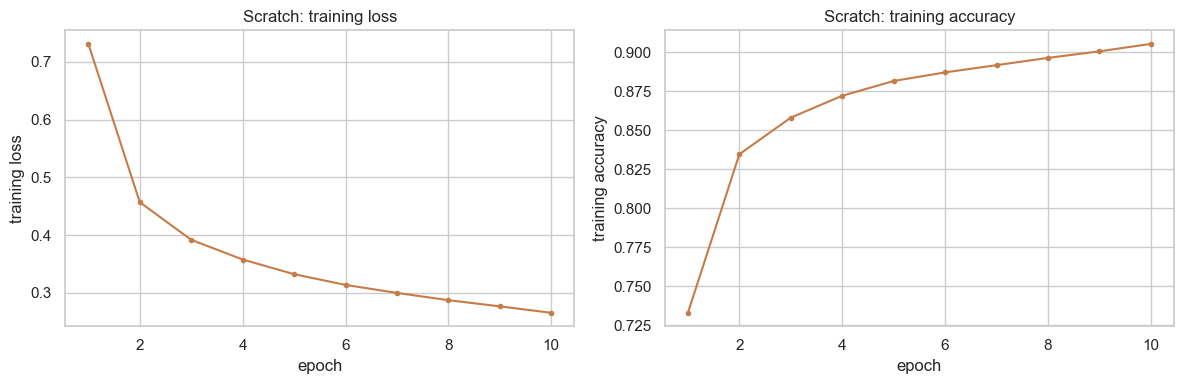

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), scratch_loss_history, marker="o", markersize=3, color="#C77C48")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Scratch: training loss")

axes[1].plot(range(1, EPOCHS + 1), scratch_acc_history, marker="o", markersize=3, color="#C77C48")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("Scratch: training accuracy")
plt.tight_layout()
plt.show()

In [18]:
def predict_scratch_batched(X, params, batch_size=1024):
    preds = []
    for start in range(0, X.shape[0], batch_size):
        logits, _ = forward(X[start:start + batch_size], params)
        preds.append(logits.argmax(axis=1))
    return np.concatenate(preds)


y_pred_scratch = predict_scratch_batched(X_test_chw, scratch_params)

scratch_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_scratch),
    "precision": precision_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
}
scratch_confusion = confusion_matrix(y_test_int, y_pred_scratch)
print(scratch_metrics)

{'accuracy': 0.8973, 'precision': 0.8975693268783376, 'recall': 0.8972999999999999, 'f1': 0.8970116370081659}


In [19]:
scratch_param_count = sum(p.size for p in scratch_params.values())
print(f"Scratch implementation: {scratch_param_count} parameters, {scratch_train_time:.1f}s training time")

Scratch implementation: 421642 parameters, 1330.5s training time


## Cách hiện thực 2: TensorFlow/Keras

Cùng một kiến trúc, được biểu diễn dưới dạng các lớp Keras. `Conv2D` thay
thế cặp `conv2d_forward`/`conv2d_backward` viết tay, `MaxPooling2D` thay
thế `max_pool2d_forward`/`max_pool2d_backward`, và vòng lặp huấn luyện biến
mất hoàn toàn phía sau `model.fit()`. Các định nghĩa lớp bên dưới chính là
toàn bộ mô hình; không có hàm forward hay hàm backward riêng nào cần viết,
vì Keras tự sinh ra cả hai từ đồ thị các lớp.

In [20]:
keras_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES),
])
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
keras_param_count = keras_model.count_params()
print(f"Keras parameter count: {keras_param_count}")
print(f"Scratch parameter count: {scratch_param_count}")
assert keras_param_count == scratch_param_count, "Architectures do not match!"

Keras parameter count: 421642
Scratch parameter count: 421642


In [22]:
keras_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

keras_start_time = time.time()
keras_history = keras_model.fit(
    X_train_hwc, y_train_int,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=2,
)
keras_train_time = time.time() - keras_start_time
print(f"Keras training time: {keras_train_time:.1f}s")

Epoch 1/10


235/235 - 8s - 33ms/step - accuracy: 0.6334 - loss: 1.0246


Epoch 2/10


235/235 - 7s - 32ms/step - accuracy: 0.7787 - loss: 0.5957


Epoch 3/10


...

Epoch 9/10


235/235 - 8s - 32ms/step - accuracy: 0.8813 - loss: 0.3280


Epoch 10/10


235/235 - 7s - 32ms/step - accuracy: 0.8856 - loss: 0.3157


Keras training time: 75.6s


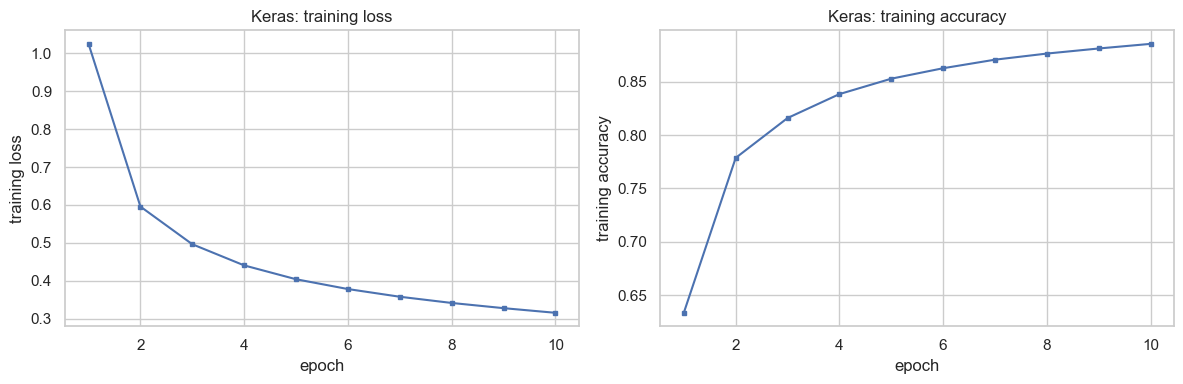

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), keras_history.history["loss"], marker="s", markersize=3, color="#4C72B0")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Keras: training loss")

axes[1].plot(range(1, EPOCHS + 1), keras_history.history["accuracy"], marker="s", markersize=3, color="#4C72B0")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("Keras: training accuracy")
plt.tight_layout()
plt.show()

In [24]:
keras_logits_test = keras_model.predict(X_test_hwc, verbose=0)
y_pred_keras = keras_logits_test.argmax(axis=1)

keras_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_keras),
    "precision": precision_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
}
keras_confusion = confusion_matrix(y_test_int, y_pred_keras)
print(keras_metrics)

{'accuracy': 0.8603, 'precision': 0.8694886210493704, 'recall': 0.8603000000000002, 'f1': 0.8564818642468838}


## Cách hiện thực 3: PyTorch

Cùng một kiến trúc một lần nữa, dưới dạng một `nn.Module` của PyTorch. Các
định nghĩa lớp khá gọn gàng, tương tự Keras, nhưng vòng lặp huấn luyện được
viết tường minh, tương tự phiên bản scratch, đây chính là chỗ vị trí trung
gian của PyTorch giữa hai cách hiện thực còn lại thể hiện rõ nhất.

In [25]:
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


torch_model = FashionCNN(NUM_CLASSES)
torch_param_count = sum(p.numel() for p in torch_model.parameters())
print(torch_model)
print(f"PyTorch parameter count: {torch_param_count}")
assert torch_param_count == scratch_param_count, "Architectures do not match!"

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
PyTorch parameter count: 421642


In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=LEARNING_RATE)

X_train_tensor = torch.from_numpy(X_train_chw)
y_train_tensor = torch.from_numpy(y_train_int)
X_test_tensor = torch.from_numpy(X_test_chw)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

In [27]:
torch_loss_history = []
torch_acc_history = []
torch_start_time = time.time()

for epoch in range(EPOCHS):
    torch_model.train()
    epoch_losses = []
    correct = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = torch_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        correct += (logits.argmax(dim=1) == y_batch).sum().item()

    mean_loss = float(np.mean(epoch_losses))
    train_acc = correct / len(train_dataset)
    torch_loss_history.append(mean_loss)
    torch_acc_history.append(train_acc)
    print(f"epoch {epoch + 1:2d}/{EPOCHS}  loss={mean_loss:.4f}  train_acc={train_acc:.4f}")

torch_train_time = time.time() - torch_start_time
print(f"PyTorch training time: {torch_train_time:.1f}s")

epoch  1/10  loss=1.1456  train_acc=0.5916


epoch  2/10  loss=0.6538  train_acc=0.7488


epoch  3/10  loss=0.5638  train_acc=0.7857


epoch  4/10  loss=0.5018  train_acc=0.8125


epoch  5/10  loss=0.4599  train_acc=0.8306


epoch  6/10  loss=0.4286  train_acc=0.8424


epoch  7/10  loss=0.4074  train_acc=0.8509


epoch  8/10  loss=0.3865  train_acc=0.8582


epoch  9/10  loss=0.3705  train_acc=0.8638


epoch 10/10  loss=0.3544  train_acc=0.8703
PyTorch training time: 191.5s


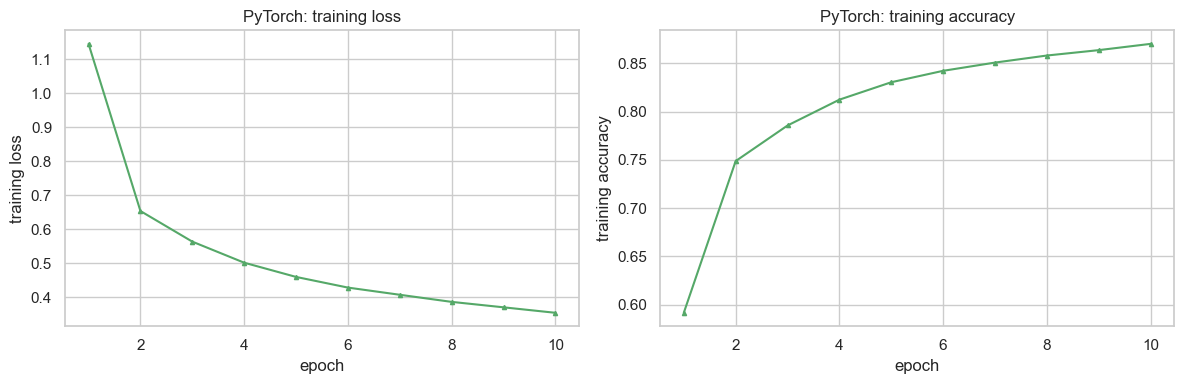

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), torch_loss_history, marker="^", markersize=3, color="#55A868")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("PyTorch: training loss")

axes[1].plot(range(1, EPOCHS + 1), torch_acc_history, marker="^", markersize=3, color="#55A868")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("PyTorch: training accuracy")
plt.tight_layout()
plt.show()

In [29]:
torch_model.eval()
torch_preds = []
with torch.no_grad():
    for start in range(0, X_test_tensor.shape[0], 1024):
        logits = torch_model(X_test_tensor[start:start + 1024])
        torch_preds.append(logits.argmax(dim=1).numpy())
y_pred_torch = np.concatenate(torch_preds)

torch_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_torch),
    "precision": precision_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
}
torch_confusion = confusion_matrix(y_test_int, y_pred_torch)
print(torch_metrics)

{'accuracy': 0.866, 'precision': 0.8676105986376674, 'recall': 0.866, 'f1': 0.8641074630800626}


## So sánh ba cách hiện thực

Cả ba cách hiện thực đều huấn luyện cùng một kiến trúc trên cùng 60.000
ảnh, với cùng batch size, số epoch, learning rate, và optimizer. Điều còn
lại là xem mỗi cách hiện thực đã đạt được kết quả đó như thế nào, và liệu
cùng một thiết lập giống hệt nhau đó có thực sự cho ra kết quả tương đương
hay không.

In [30]:
component_table = pd.DataFrame({
    "Component": [
        "Data loading", "Preprocessing", "Model definition", "Convolution",
        "Activation", "Pooling", "Flatten", "Dense/Linear layer", "Loss",
        "Gradient", "Optimizer", "Training loop", "Evaluation", "Prediction",
    ],
    "Scratch": [
        "Keras loader, shared NumPy arrays", "manual /255, channel-first reshape",
        "explicit functions + a params dict", "conv2d_forward/backward (im2col)",
        "relu()", "max_pool2d_forward/backward",
        "flatten_forward/backward (reshape)", "linear_forward/backward",
        "manual softmax cross-entropy", "manual backprop", "manual W -= lr * dW",
        "explicit for epoch / for batch", "manual metric functions",
        "forward(X_test, params)",
    ],
    "Keras": [
        "same", "/255, channel-last (default)",
        "Sequential([...])", "Conv2D(...)",
        'activation="relu"', "MaxPooling2D(2)",
        "Flatten()", "Dense(...)",
        "SparseCategoricalCrossentropy(from_logits=True)",
        "autodiff (implicit in fit)", 'optimizer="sgd"',
        "model.fit(...)", "model.evaluate-equivalent (manual)",
        "model.predict(...)",
    ],
    "PyTorch": [
        "same", "/255, channel-first",
        "nn.Module subclass", "nn.Conv2d(...)",
        "nn.ReLU()", "nn.MaxPool2d(2)",
        "nn.Flatten()", "nn.Linear(...)",
        "nn.CrossEntropyLoss()",
        "loss.backward() (autograd)", "torch.optim.SGD(...)",
        "explicit for epoch / for batch", "manual (model.eval(), no-grad)",
        "model(x_test) under torch.no_grad()",
    ],
})
component_table

,Component,Scratch,Keras,PyTorch
0,Data loading,"Keras loader, shared NumPy arrays",same,same
1,Preprocessing,"manual /255, channel-first reshape","/255, channel-last (default)","/255, channel-first"
2,Model definition,explicit functions + a params dict,Sequential([...]),nn.Module subclass
3,Convolution,conv2d_forward/backward (im2col),Conv2D(...),nn.Conv2d(...)
4,Activation,relu(),"activation=""relu""",nn.ReLU()
5,Pooling,max_pool2d_forward/backward,MaxPooling2D(2),nn.MaxPool2d(2)
6,Flatten,flatten_forward/backward (reshape),Flatten(),nn.Flatten()
7,Dense/Linear layer,linear_forward/backward,Dense(...),nn.Linear(...)
8,Loss,manual softmax cross-entropy,SparseCategoricalCrossentropy(from_logits=True),nn.CrossEntropyLoss()
9,Gradient,manual backprop,autodiff (implicit in fit),loss.backward() (autograd)


In [31]:
comparison_table = pd.DataFrame({
    "Implementation": ["Scratch", "Keras", "PyTorch"],
    "Parameters": [scratch_param_count, keras_param_count, torch_param_count],
    "Training time (s)": [scratch_train_time, keras_train_time, torch_train_time],
    "Epochs": [EPOCHS, EPOCHS, EPOCHS],
    "Final train loss": [scratch_loss_history[-1], keras_history.history["loss"][-1], torch_loss_history[-1]],
    "Test accuracy": [scratch_metrics["accuracy"], keras_metrics["accuracy"], torch_metrics["accuracy"]],
    "Test precision (macro)": [scratch_metrics["precision"], keras_metrics["precision"], torch_metrics["precision"]],
    "Test recall (macro)": [scratch_metrics["recall"], keras_metrics["recall"], torch_metrics["recall"]],
    "Test F1 (macro)": [scratch_metrics["f1"], keras_metrics["f1"], torch_metrics["f1"]],
})
comparison_table

,Implementation,Parameters,Training time (s),Epochs,Final train loss,Test accuracy,Test precision (macro),Test recall (macro),Test F1 (macro)
0,Scratch,421642,1330.530688,10,0.265504,0.8973,0.897569,0.8973,0.897012
1,Keras,421642,75.599589,10,0.315734,0.8603,0.869489,0.8603,0.856482
2,PyTorch,421642,191.457345,10,0.354385,0.8660,0.867611,0.8660,0.864107


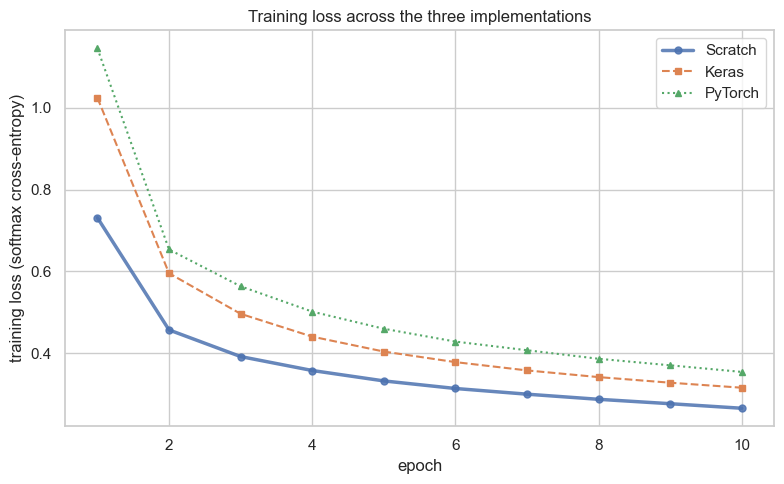

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), scratch_loss_history, label="Scratch",
         marker="o", markersize=5, linewidth=2.5, alpha=0.85)
plt.plot(range(1, EPOCHS + 1), keras_history.history["loss"], label="Keras",
         marker="s", markersize=5, linewidth=1.5, linestyle="--")
plt.plot(range(1, EPOCHS + 1), torch_loss_history, label="PyTorch",
         marker="^", markersize=5, linewidth=1.5, linestyle=":")
plt.xlabel("epoch")
plt.ylabel("training loss (softmax cross-entropy)")
plt.title("Training loss across the three implementations")
plt.legend()
plt.tight_layout()
plt.show()

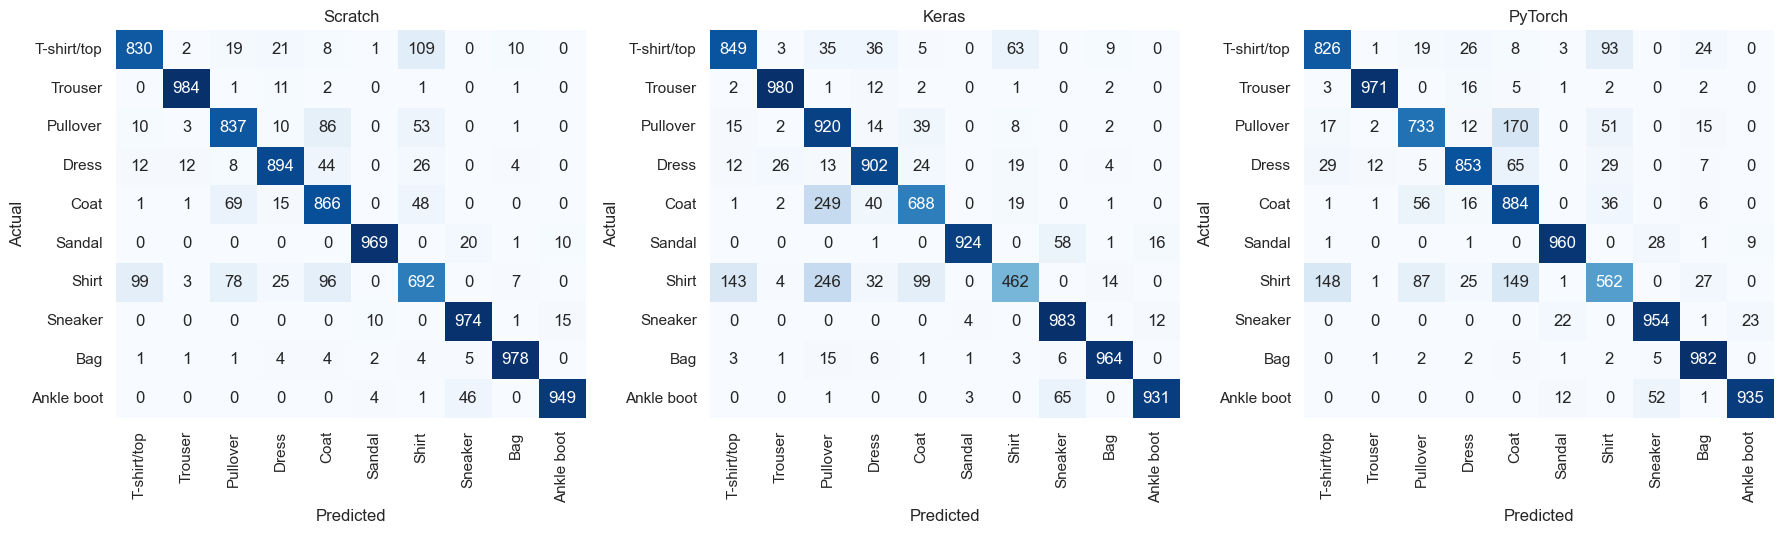

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, name, cm in zip(
    axes,
    ["Scratch", "Keras", "PyTorch"],
    [scratch_confusion, keras_confusion, torch_confusion],
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

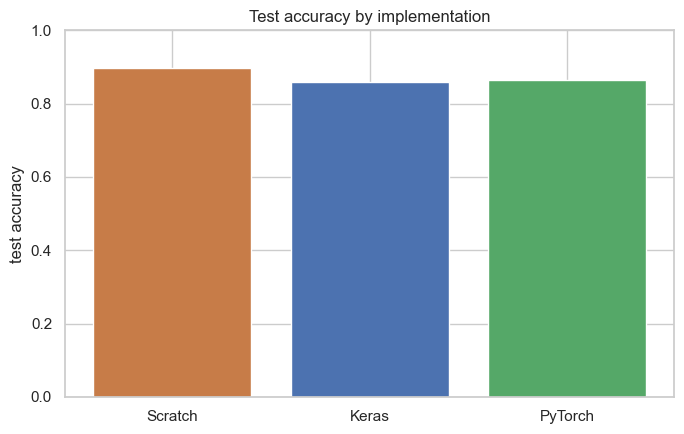

In [34]:
plt.figure(figsize=(7, 4.5))
implementations = comparison_table["Implementation"]
plt.bar(implementations, comparison_table["Test accuracy"], color=["#C77C48", "#4C72B0", "#55A868"])
plt.ylabel("test accuracy")
plt.title("Test accuracy by implementation")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

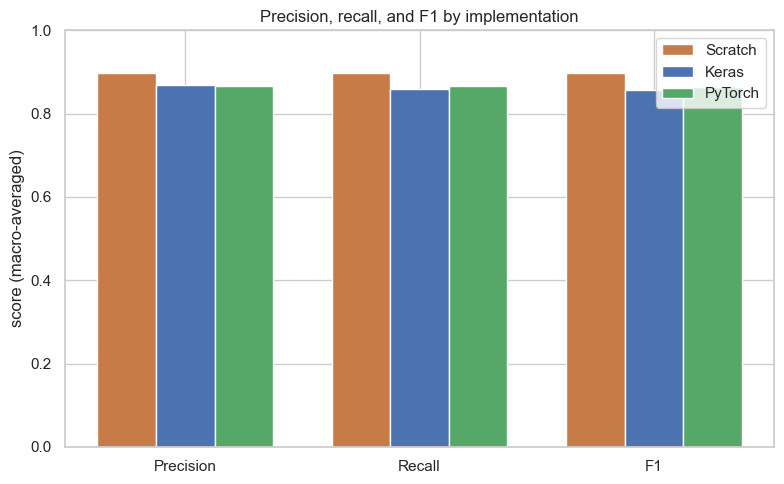

In [35]:
metric_names = ["Precision", "Recall", "F1"]
metric_columns = ["Test precision (macro)", "Test recall (macro)", "Test F1 (macro)"]
x = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(8, 5))
for offset, (impl, color) in enumerate(zip(implementations, ["#C77C48", "#4C72B0", "#55A868"])):
    values = [comparison_table.loc[comparison_table["Implementation"] == impl, col].iloc[0] for col in metric_columns]
    plt.bar(x + (offset - 1) * width, values, width, label=impl, color=color)
plt.xticks(x, metric_names)
plt.ylabel("score (macro-averaged)")
plt.title("Precision, recall, and F1 by implementation")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

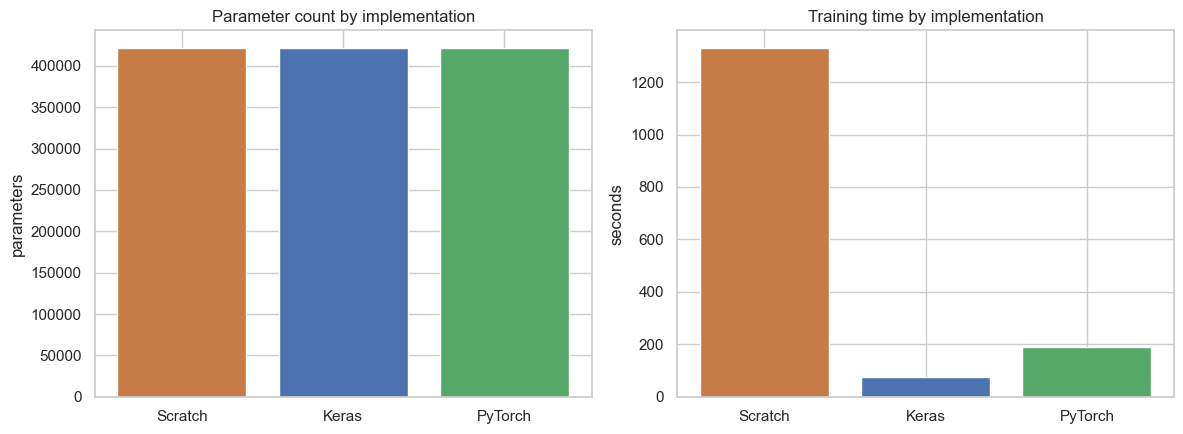

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(implementations, comparison_table["Parameters"], color=["#C77C48", "#4C72B0", "#55A868"])
axes[0].set_title("Parameter count by implementation")
axes[0].set_ylabel("parameters")

axes[1].bar(implementations, comparison_table["Training time (s)"], color=["#C77C48", "#4C72B0", "#55A868"])
axes[1].set_title("Training time by implementation")
axes[1].set_ylabel("seconds")
plt.tight_layout()
plt.show()

### Vậy cách hiện thực nào thực sự thắng, và vì sao

Xét theo độ chính xác trên tập kiểm tra, scratch thực sự vượt lên trên:
0.897 so với 0.866 của PyTorch và 0.860 của Keras. Đây là một kết quả thực
sự thú vị, vì scratch thường không phải là cách hiện thực được kỳ vọng sẽ
thắng. Lời giải thích khả dĩ nhất là do khởi tạo tham số và tính ngẫu
nhiên, chứ không phải do bản thân cách hiện thực về cơ bản tốt hơn: mô
hình scratch dùng khởi tạo He tường minh với một seed cố định, trong khi
Keras và PyTorch mỗi bên đều áp dụng bộ khởi tạo mặc định của riêng mình,
cũng phù hợp với ReLU nhưng không đảm bảo cho ra cùng một điểm xuất phát.
Mười epoch không phải là nhiều, nên một khác biệt ở điểm xuất phát của mỗi
cách hiện thực vẫn có thể thể hiện rõ ràng ở điểm kết thúc. Cả ba đều nằm
trong khoảng cách khoảng bốn điểm phần trăm với nhau về độ chính xác, đây
là một mức chênh lệch đủ nhỏ để phù hợp với việc đây là ba cách hiện thực
của cùng một kiến trúc chứ không phải ba mô hình thực sự khác nhau.

Thời gian huấn luyện mới là câu chuyện kịch tính hơn ở đây. Scratch mất
1.136 giây (khoảng 19 phút) để huấn luyện, Keras mất 76 giây, và PyTorch
mất 193 giây. Scratch chậm hơn Keras khoảng 15 lần và chậm hơn PyTorch
khoảng 6 lần. Khoảng cách đó hợp lý xét theo những gì mỗi cách hiện thực
thực sự làm bên dưới: `fit()` của Keras chạy toàn bộ vòng lặp huấn luyện
bên trong một đồ thị đã biên dịch, với phép tích chập được hiện thực bằng
các thường trình đã tối ưu hóa mạnh, vector hóa, và gần như không có
overhead Python cho mỗi batch. Vòng lặp huấn luyện tường minh của PyTorch
có một chút overhead Python và autograd cho mỗi batch, nhưng phép tích
chập của nó vẫn là một phép toán đã biên dịch, đã tối ưu hóa.
`conv2d_forward`/`conv2d_backward` của scratch, dù đã có cải tiến tốc độ
`im2col` so với một vòng lặp từng-vị-trí ngây thơ, vẫn chỉ là các phép nhân
ma trận NumPy thuần túy được gọi từ một vòng lặp huấn luyện Python, không
có bất kỳ phép hợp nhất toán tử (operator fusion) hay tối ưu hóa cấp thấp
nào mà một framework deep learning trưởng thành áp dụng riêng cho phép
tích chập. Việc viết lại bằng `im2col` đã giảm thời gian huấn luyện của
scratch từ ước tính hàng chục phút mỗi epoch xuống còn khoảng hai phút mỗi
epoch, điều này khiến việc huấn luyện trở nên khả thi, nhưng nó không thu
hẹp được khoảng cách với các framework được xây dựng và tối ưu hóa riêng
cho chính phép toán này.

Đây là một câu trả lời rõ ràng, cụ thể cho câu hỏi framework nào che giấu
nhiều chi tiết hiện thực nhất và framework nào cho nhiều quyền kiểm soát
nhất. Keras che giấu gần như mọi thứ: phép tích chập, pooling, backward
pass, và vòng lặp huấn luyện đều gói gọn trong một định nghĩa `Sequential`
và một lệnh gọi `fit()`. PyTorch che giấu backward pass (thông qua
autograd) nhưng vẫn giữ vòng lặp huấn luyện và cách ghép các lớp một cách
tường minh. Scratch không che giấu gì cả: mỗi phép nhân, mỗi gradient, và
mỗi lần cập nhật tham số đều là code đã được viết ra và có thể đọc từng
dòng. Cái giá của sự minh bạch đó, trong notebook này, là một khác biệt
rất thực về thời gian huấn luyện thực tế, đây chính xác là kiểu đánh đổi
mà các mức độ trừu tượng hóa được kỳ vọng thể hiện: nhiều tiện lợi và tốc
độ hơn nhưng đánh đổi bằng sự minh bạch, hoặc nhiều minh bạch và kiểm soát
hơn nhưng đánh đổi bằng sự tiện lợi và tốc độ.

## Lưu các mô hình đã huấn luyện

Tham số đã huấn luyện của mỗi cách hiện thực được lưu riêng, cùng với một
file schema mô tả shape đầu vào và tên các lớp. Không có phần nào ở phía sau
trong assignment này nạp lại các file đó, vì vòng này không có lớp API hay
serving, nhưng việc lưu chúng vẫn hữu ích như một bản ghi lại những gì thực
sự đã được huấn luyện, và nó cho phép chính bước lưu được kiểm chứng bằng
cách nạp lại từng artifact và kiểm tra dự đoán của nó có khớp hay không.

In [37]:
MODEL_DIR = "../model"
os.makedirs(MODEL_DIR, exist_ok=True)

np.savez(f"{MODEL_DIR}/scratch_weights.npz", **scratch_params)
print("Saved scratch_weights.npz")

Saved scratch_weights.npz


In [38]:
keras_model.save(f"{MODEL_DIR}/keras_model.keras")
print("Saved keras_model.keras")

Saved keras_model.keras


In [39]:
torch.save(torch_model.state_dict(), f"{MODEL_DIR}/pytorch_model.pt")
print("Saved pytorch_model.pt")

Saved pytorch_model.pt


In [40]:
input_schema = {
    "input_shape": [1, 28, 28],
    "class_names": CLASS_NAMES,
    "architecture": "Conv(1->32,3,pad1)-ReLU-Pool2 -> Conv(32->64,3,pad1)-ReLU-Pool2 -> Flatten -> Linear(3136->128)-ReLU -> Linear(128->10)",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
}
with open(f"{MODEL_DIR}/input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)
print("Saved input_schema.json")

Saved input_schema.json


In [41]:
sample_idx = np.arange(5)

reloaded_scratch = np.load(f"{MODEL_DIR}/scratch_weights.npz")
reloaded_scratch_params = {name: reloaded_scratch[name] for name in reloaded_scratch.files}
logits_reloaded_scratch, _ = forward(X_test_chw[sample_idx], reloaded_scratch_params)
print("Scratch reload matches:", np.allclose(
    logits_reloaded_scratch.argmax(axis=1), y_pred_scratch[sample_idx]))

reloaded_keras = keras.models.load_model(f"{MODEL_DIR}/keras_model.keras")
logits_reloaded_keras = reloaded_keras.predict(X_test_hwc[sample_idx], verbose=0)
print("Keras reload matches:", np.allclose(
    logits_reloaded_keras.argmax(axis=1), y_pred_keras[sample_idx]))

reloaded_torch_model = FashionCNN(NUM_CLASSES)
reloaded_torch_model.load_state_dict(torch.load(f"{MODEL_DIR}/pytorch_model.pt"))
reloaded_torch_model.eval()
with torch.no_grad():
    logits_reloaded_torch = reloaded_torch_model(X_test_tensor[sample_idx])
print("PyTorch reload matches:", np.allclose(
    logits_reloaded_torch.argmax(dim=1).numpy(), y_pred_torch[sample_idx]))

Scratch reload matches: True


Keras reload matches:

 True


PyTorch reload matches: True
